In [1]:
from ase.io import read, iread
import glob
from itertools import groupby
import pickle
import os
import copy
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import linregress
from collections import Counter

from aseMolec import pltProps as pp
from aseMolec import anaAtoms as aa

import helper_funcs as hf

# Colourblind friendly colours
import tol_colors as tc
cset = tc.tol_cset('bright')
plt.rc('axes', prop_cycle=plt.cycler('color', list(cset)))

fsize = 24
plt.rcParams.update({'font.size': fsize})

dynamics_path = '../publication/dynamics/'
static_path = '../publication/static_tests/'


# Data set statistics

## Small data set (SD22NQQ)

In [13]:
import pickle
from ase.io import read

pkl_name = './SD22NQQ_xyz.pkl'

SD22NQQ1 = read(f'{static_path}/SDN22NQQ/wB97X/SEED1/DSET1/train_data/SD22NQQ1_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms
SD22NQQ2 = read(f'{static_path}/SDN22NQQ/wB97X/SEED1/DSET2/train_data/SD22NQQ2_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms
SD22NQQ3 = read(f'{static_path}/SDN22NQQ/wB97X/SEED1/DSET3/train_data/SD22NQQ3_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms

xyz_dict = {'SD22NQQ1':SD22NQQ1, 'SD22NQQ2':SD22NQQ2, 'SD22NQQ3':SD22NQQ3}
with open(pkl_name, 'wb') as f:
    pickle.dump(xyz_dict, f)

In [18]:
num_atoms_small = sum([len(a.numbers) for a in SD22NQQ1])
print(num_atoms_small)

327089


### Cluster composition

In [2]:
import pickle

pkl_name = './SD22NQQ_xyz.pkl'

with open(pkl_name, 'rb') as f:
    SD22NQQ_dict = pickle.load(f)

SD22NQQ1_stats = np.histogram(np.array([at.info['Nmols'] for at in SD22NQQ_dict['SD22NQQ1']]), [1,2,3,4,5,6,7])[0]
SD22NQQ2_stats = np.histogram(np.array([at.info['Nmols'] for at in SD22NQQ_dict['SD22NQQ2']]), [1,2,3,4,5,6,7])[0]
SD22NQQ3_stats = np.histogram(np.array([at.info['Nmols'] for at in SD22NQQ_dict['SD22NQQ3']]), [1,2,3,4,5,6,7])[0]
SD22NQQ_stats_dict = {'SD22NQQ1':SD22NQQ1_stats, 'SD22NQQ2':SD22NQQ2_stats, 'SD22NQQ3':SD22NQQ3_stats}

SD22NQQ_stats_df = pd.DataFrame(SD22NQQ_stats_dict)
SD22NQQ_stats_df.index.name = 'Cluster size, $N_\\text{mols}$'
SD22NQQ_stats_df.index += 1
SD22NQQ_stats_df

,SD22NQQ1,SD22NQQ2,SD22NQQ3
"Cluster size, $N_\text{mols}$",,,
1,900,900,900
2,1470,1470,1470
3,2001,2001,2001
4,1917,1917,1917
5,1464,1464,1464
6,264,264,264


In [3]:
SD22NQQ_stats_df.sum()

SD22NQQ1    8016
SD22NQQ2    8016
SD22NQQ3    8016
dtype: int64

In [4]:
(SD22NQQ_stats_df.index*SD22NQQ_stats_df['SD22NQQ1']).sum()

26415

### Molecular composition

In [5]:
data = 'SD22NQQ1'
print(f'{data}:')
comp = hf.collect_comp(SD22NQQ_dict[data])
SD22NQQ1_comp_flat = hf.flatten_comp(comp)
SD22NQQ1_comp_flat

SD22NQQ1:


,EMC,EC,EC and EMC and other,EC or EMC and other,Other
1,150,150,0,0,600
2,70,70,70,560,700
3,40,40,220,1073,628
4,41,200,189,706,781
5,25,322,139,344,634
6,0,0,144,110,10


In [6]:
data = 'SD22NQQ2'
print(f'{data}:')
comp = hf.collect_comp(SD22NQQ_dict[data])
SD22NQQ1_comp_flat = hf.flatten_comp(comp)
SD22NQQ1_comp_flat

SD22NQQ2:


,EMC,EC,EC and EMC and other,EC or EMC and other,Other
1,150,150,0,0,600
2,70,70,70,560,700
3,40,40,220,1073,628
4,41,200,189,706,781
5,25,322,139,344,634
6,0,0,144,110,10


In [7]:
data = 'SD22NQQ3'
print(f'{data}:')
comp = hf.collect_comp(SD22NQQ_dict[data])
SD22NQQ1_comp_flat = hf.flatten_comp(comp)
SD22NQQ1_comp_flat

SD22NQQ3:


,EMC,EC,EC and EMC and other,EC or EMC and other,Other
1,150,150,0,0,600
2,70,70,70,560,700
3,40,40,220,1073,628
4,41,200,189,706,781
5,25,322,139,344,634
6,0,0,144,110,10


## Medium data set (SD22NQ)

In [ ]:
import pickle
from ase.io import read

pkl_name = './SD22NQ_xyz.pkl'

SD22NQ1 = read(f'{static_path}/SDN22NQ/wB97X/SEED1/DSET1/train_data/SD22NQ1_wB97XD3BJ_Psi4.xyz', ':')
SD22NQ2 = read(f'{static_path}/SDN22NQ/wB97X/SEED1/DSET2/train_data/SD22NQ2_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms
SD22NQ3 = read(f'{static_path}/SDN22NQ/wB97X/SEED1/DSET3/train_data/SD22NQ3_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms

xyz_dict = {'SD22NQ1':SD22NQ1, 'SD22NQ2':SD22NQ2, 'SD22NQ3':SD22NQ3}
with open(pkl_name, 'wb') as f:
    pickle.dump(xyz_dict, f)

In [20]:
num_atoms_medium = sum([len(a.numbers) for a in SD22NQ1])
print(num_atoms_medium)

1269916


### Cluster composition

In [8]:
import pickle

pkl_name = './SD22NQ_xyz.pkl'

with open(pkl_name, 'rb') as f:
    SD22NQ_dict = pickle.load(f)

SD22NQ1_stats = np.histogram(np.array([at.info['Nmols'] for at in SD22NQ_dict['SD22NQ1']]), [1,2,3,4,5,6,7])[0]
SD22NQ2_stats = np.histogram(np.array([at.info['Nmols'] for at in SD22NQ_dict['SD22NQ2']]), [1,2,3,4,5,6,7])[0]
SD22NQ3_stats = np.histogram(np.array([at.info['Nmols'] for at in SD22NQ_dict['SD22NQ3']]), [1,2,3,4,5,6,7])[0]
SD22NQ_stats_dict = {'SD22NQ1':SD22NQ1_stats, 'SD22NQ2':SD22NQ2_stats, 'SD22NQ3':SD22NQ3_stats}

SD22NQ_stats_df = pd.DataFrame(SD22NQ_stats_dict)
SD22NQ_stats_df.index.name = 'Cluster size, $N_\\text{mols}$'
SD22NQ_stats_df.index += 1
SD22NQ_stats_df

,SD22NQ1,SD22NQ2,SD22NQ3
"Cluster size, $N_\text{mols}$",,,
1,7880,7880,7880
2,18253,18253,18253
3,10176,10176,10176
4,4787,4787,4787
5,1464,1464,1464
6,264,264,264


In [9]:
SD22NQ_stats_df.sum()

SD22NQ1    42824
SD22NQ2    42824
SD22NQ3    42824
dtype: int64

In [10]:
(SD22NQ_stats_df.index*SD22NQ_stats_df['SD22NQ1']).sum()

102966

### Molecular composition

In [11]:
data = 'SD22NQ1'
print(f'{data}:')
comp = hf.collect_comp(SD22NQ_dict[data])
SD22NQ1_comp_flat = hf.flatten_comp(comp)
SD22NQ1_comp_flat

SD22NQ1:


,EMC,EC,EC and EMC and other,EC or EMC and other,Other
1,887,2354,0,0,4639
2,1069,190,1092,9088,6814
3,178,1091,516,2433,5958
4,41,1528,189,706,2323
5,25,322,139,344,634
6,0,0,144,110,10


In [12]:
data = 'SD22NQ2'
print(f'{data}:')
comp = hf.collect_comp(SD22NQ_dict[data])
SD22NQ2_comp_flat = hf.flatten_comp(comp)
SD22NQ2_comp_flat

SD22NQ2:


,EMC,EC,EC and EMC and other,EC or EMC and other,Other
1,887,2354,0,0,4639
2,1069,190,1092,9088,6814
3,178,1091,516,2433,5958
4,41,1528,189,706,2323
5,25,322,139,344,634
6,0,0,144,110,10


In [13]:
data = 'SD22NQ3'
print(f'{data}:')
comp = hf.collect_comp(SD22NQ_dict[data])
SD22NQ3_comp_flat = hf.flatten_comp(comp)
SD22NQ3_comp_flat

SD22NQ3:


,EMC,EC,EC and EMC and other,EC or EMC and other,Other
1,887,2354,0,0,4639
2,1069,190,1092,9088,6814
3,178,1091,516,2433,5958
4,41,1528,189,706,2323
5,25,322,139,344,634
6,0,0,144,110,10


## Large data set (SD22N)

In [166]:
import pickle
from ase.io import read

pkl_name = './SD22N_xyz.pkl'

SD22N = read(f'{static_path}/SDN22N/wB97X/SEED1/DSET1/train_data/SD22N_wB97XD3BJ_Psi4.xyz', ':')

xyz_dict = {'SD22N':SD22N}
with open(pkl_name, 'wb') as f:
    pickle.dump(xyz_dict, f)

In [25]:
num_atoms_large = np.average([len(a.numbers) for a in SD22N])
print(num_atoms_large)

21.665446480092324


### Cluster composition

In [14]:
import pickle

pkl_name = './SD22N_xyz.pkl'

with open(pkl_name, 'rb') as f:
    SD22N_dict = pickle.load(f)

SD22N_stats = np.histogram(np.array([at.info['Nmols'] for at in SD22N_dict['SD22N']]), [1,2,3,4,5,6,7])[0]
SD22N_stats_dict = {'SD22N':SD22N_stats}

SD22N_stats_df = pd.DataFrame(SD22N_stats_dict)
SD22N_stats_df.index.name = 'Cluster size, $N_\\text{mols}$'
SD22N_stats_df.index += 1
SD22N_stats_df

,SD22N
"Cluster size, $N_\text{mols}$",
1,77880
2,82253
3,37176
4,17787
5,6464
6,264


In [15]:
SD22N_stats_df.sum()

SD22N    221824
dtype: int64

In [16]:
(SD22N_stats_df.index*SD22N_stats_df['SD22N']).sum()

458966

### Molecular composition

In [17]:
data = 'SD22N'
print(f'{data}:')
comp = hf.collect_comp(SD22N_dict[data])
SD22N_comp_flat = hf.flatten_comp(comp)
SD22N_comp_flat

SD22N:


,EMC,EC,EC and EMC and other,EC or EMC and other,Other
1,887,72354,0,0,4639
2,1069,40190,1092,9088,30814
3,178,23091,516,2433,10958
4,41,11528,189,706,5323
5,25,5322,139,344,634
6,0,0,144,110,10


## Overall statistics

### Expected cluster sizes

In [18]:
dfs = {
    'SD22NQQ':SD22NQQ_stats_df['SD22NQQ1'],
    'SD22NQ':SD22NQ_stats_df['SD22NQ1'],
    'SD22N':SD22N_stats_df['SD22N'],
}
stats_df = pd.concat(dfs.values(), axis=1, keys=dfs.keys())

In [19]:
tot = stats_df.aggregate('sum', axis=0)
stats_dist_df = stats_df/tot
clusters = np.arange(1, len(stats_dist_df)+1)
print(clusters)
expectation = (stats_dist_df*clusters[:,None]).aggregate('sum', axis=0).round(decimals=2)
second_moment = (stats_dist_df*clusters[:,None]**2).aggregate('sum', axis=0).round(decimals=2)
variance = second_moment-expectation**2
print(expectation)
print(variance**0.5)
SD22NQQ_cluster_size, SD22NQ_cluster_size, SD22N_cluster_size = expectation

[1 2 3 4 5 6]
SD22NQQ    3.30
SD22NQ     2.40
SD22N      2.07
dtype: float64
SD22NQQ    1.334166
SD22NQ     1.063015
SD22N      1.055983
dtype: float64


In [22]:
a = expectation**2/variance**0.5
a

SD22NQQ    8.162400
SD22NQ     5.418552
SD22N      4.057736
dtype: float64

In [23]:
l = expectation/variance**0.5
l

SD22NQQ    2.473455
SD22NQ     2.257730
SD22N      1.960259
dtype: float64

### Visual distributions

/tmp/ipykernel_297349/1673203119.py:51: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs[-1].set_ylim([0,1e6])


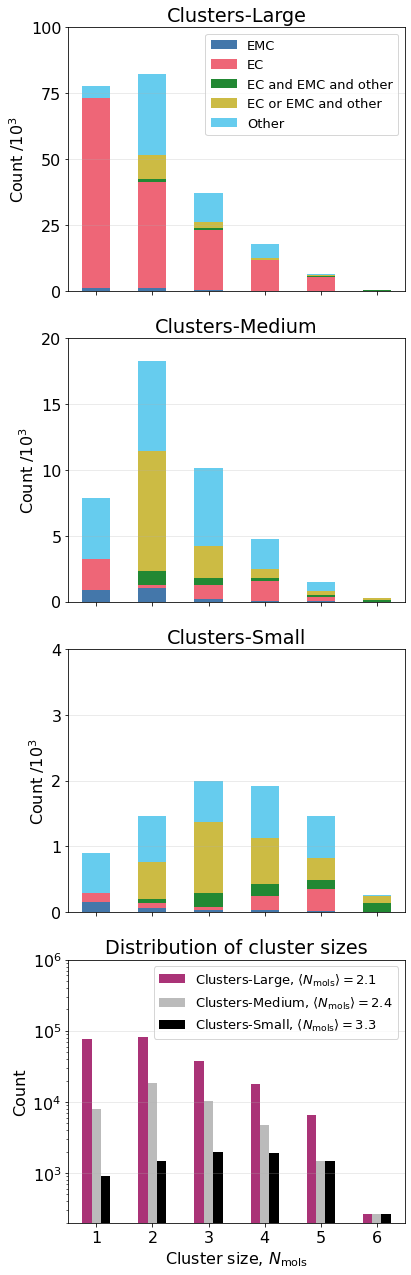

In [114]:
scale = 2
fsize = 8*scale
plt.rcParams.update({'font.size': fsize})

fig, axs = plt.subplots(4,1, figsize=(3*scale, 9*scale), sharey=False, sharex=True)
comps = {
    'SD22N':SD22N_comp_flat,
    'SD22NQ':SD22NQ1_comp_flat,
    'SD22NQQ':SD22NQQ1_comp_flat,
}

name_map = {
    'SD22NQQ':'Clusters-Small',
    'SD22NQ':'Clusters-Medium',
    'SD22N':'Clusters-Large',
}

axs = axs.ravel()
for i, (ax, (name, data)) in enumerate(zip(axs, comps.items())):
    d = data/1e3
    if i == 2:
        ax.set_ylim([0,4])
        ax.set_yticks(np.arange(0,5,1))
    elif i == 1:
        ax.set_ylim([0,20])
        ax.set_yticks(np.arange(0,21,5))
    elif i == 0:
        ax.set_ylim([0,100])
        ax.set_yticks(np.arange(0,101,25))

    d.plot.bar(ax=ax, legend=False, stacked=True, rot=0)
    
    ax.set_title(name_map[name])
    ax.grid(axis='y', alpha=0.3)


    ax.set_ylabel('Count /$10^3$')
axs[0].legend(fontsize=fsize-3, ncols=1, loc='upper right')

axs[-1].set_title('Distribution of cluster sizes')
scaled_stats_df = stats_df
scaled_stats_df[['SD22N', 'SD22NQ', 'SD22NQQ']].plot.bar(
#stats_df.plot.bar(
    ylabel='Count',
	rot=0,
	ax=axs[-1],
    color=cset[5:],
    #color=[cset.red, cset.yellow, cset.cyan],
)
axs[-1].set_yscale('log')
axs[-1].set_ylim([0,1e6])

axs[-1].grid(axis='y', alpha=0.3)
axs[-1].legend(
    [
        f'Clusters-Large, $\\langle N_\\text{{mols}} \\rangle = {SD22N_cluster_size:.1f}$',
        f'Clusters-Medium, $\\langle N_\\text{{mols}} \\rangle = {SD22NQ_cluster_size:.1f}$',
        f'Clusters-Small, $\\langle N_\\text{{mols}} \\rangle = {SD22NQQ_cluster_size:.1f}$',
    ],
    fontsize=fsize-3,
)
plt.tight_layout()
plt.savefig('../publication/plots/part2_statistics.pdf', format='pdf', dpi=1200)

/tmp/ipykernel_752556/2151152737.py:47: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs[-1].set_ylim([0,1e6])


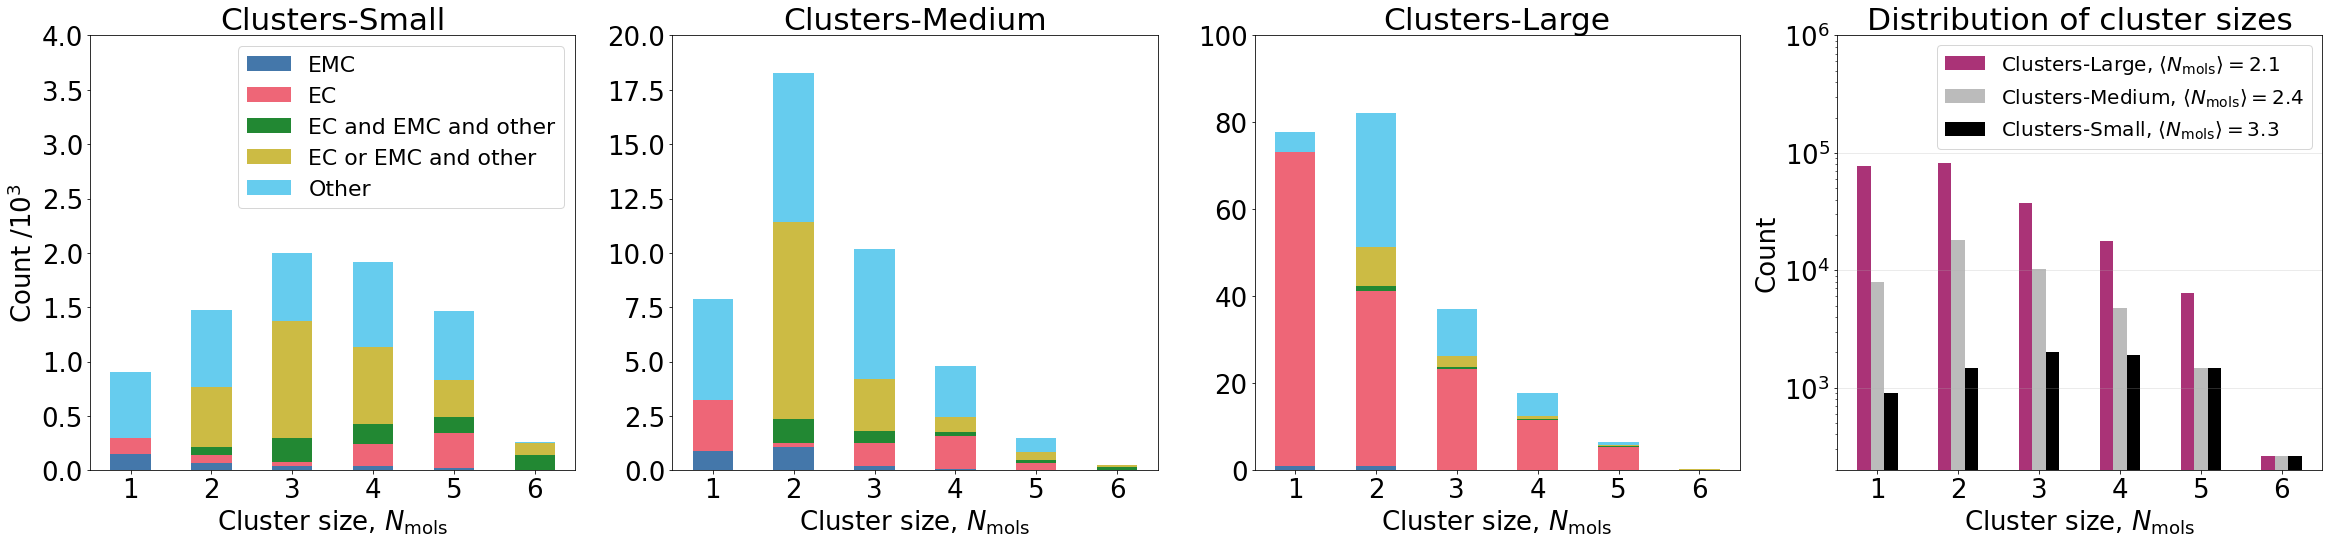

In [26]:
fsize = 26
plt.rcParams.update({'font.size': fsize})

fig, axs = plt.subplots(1,4, figsize=(10*4, 8*1), sharey=False)
comps = {
    'SD22NQQ':SD22NQQ1_comp_flat,
    'SD22NQ':SD22NQ1_comp_flat,
    'SD22N':SD22N_comp_flat,
}

name_map = {
    'SD22NQQ':'Clusters-Small',
    'SD22NQ':'Clusters-Medium',
    'SD22N':'Clusters-Large',
}

axs = axs.ravel()
for i, (ax, (name, data)) in enumerate(zip(axs, comps.items())):
    d = data/1e3
    if i == 0:
        ax.set_ylim([0,4])
    elif i == 1:
        ax.set_ylim([0,20])
    elif i == 2:
        ax.set_ylim([0,100])

    d.plot.bar(ax=ax, legend=False, stacked=True, rot=0)
    if i == 0: ax.legend(fontsize=fsize-4, ncols=1)
    ax.set_title(name_map[name])

    if i == 0: ax.set_ylabel('Count /$10^3$')
    ax.set_xlabel('Cluster size, $N_\\text{mols}$')



axs[-1].set_title('Distribution of cluster sizes')
scaled_stats_df = stats_df
scaled_stats_df[['SD22N', 'SD22NQ', 'SD22NQQ']].plot.bar(
#stats_df.plot.bar(
    ylabel='Count',
	rot=0,
	ax=axs[-1],
    color=cset[5:],
    #color=[cset.red, cset.yellow, cset.cyan],
)
axs[-1].set_yscale('log')
axs[-1].set_ylim([0,1e6])

axs[-1].grid(axis='y', alpha=0.3)
axs[-1].legend(
    [
        f'Clusters-Large, $\\langle N_\\text{{mols}} \\rangle = {SD22N_cluster_size:.1f}$',
        f'Clusters-Medium, $\\langle N_\\text{{mols}} \\rangle = {SD22NQ_cluster_size:.1f}$',
        f'Clusters-Small, $\\langle N_\\text{{mols}} \\rangle = {SD22NQQ_cluster_size:.1f}$',
    ],
    fontsize=fsize-6,
)


In [ ]:
def self_interaction_mask(array):
    SI = [[0 if a==b else 1 for b in array] for a in array]
    return np.array(SI)


def get_pair_histogram(atoms, rmax, nbins, pbc=False, probability=False, inter_only=False, threshold=None):
    if pbc:
        distances = atoms.get_all_distances(mic=True)
    else:
        distances = atoms.get_all_distances()
    
    if inter_only:
        molIDs = atoms.arrays['molID']
        distances = distances*self_interaction_mask(molIDs)
        #distances[self_interaction_mask(molIDs) == 0] = 0
        
        if threshold is not None:
            ids = np.where((distances>0) & (distances<threshold))[0]
            if len(ids) > 0:
                print(ids)

    iu = np.triu_indices(len(distances), k=1)
    dists = distances[iu]
    del iu
    dists_cutoff = dists[dists<=rmax]
    
    dr = rmax/nbins
    edges = np.arange(0, rmax+dr, dr)
    #counts, bins = np.histogram(dists_cutoff, bins=edges)
    counts, bins = np.histogram(dists, bins=edges)
    #counts = counts/len(atoms) ## new
    V = 4*np.pi*rmax**3/3 ## new
    V = 1
    #counts = np.cumsum(counts) ## new

    
    #n_ats = len(dists_cutoff)
    #n_ats = np.cumsum(counts)
    #print(n_ats)
    n_ats = len(atoms)
    #n_ats = np.count_nonzero(dists_cutoff)
    r = (bins[:-1]+bins[1:])/2
    #r = (bins[1:]+bins[:-1])/2
    #n_r = 2*counts/n_ats/dr ## old
    n_r = counts/(n_ats*V) ## new
    #n_r *= 2/dr
    del atoms
    del dists
    if probability:
        p_r = n_r/np.cumsum(n_r)*dr
        return p_r, r
    else:
        return n_r, r


def get_pair_histograms(atoms, rmax, nbins, pbc=False, probability=False, inter_only=False, use_max=False):
    if inter_only and ('molID' not in atoms[0].arrays):
        aa.find_molecs(atoms, fct=1.0)

    max_n_r = None
    for k, a in enumerate(atoms):
        if k == 0:
            n_r, r = get_pair_histogram(a, rmax=rmax, nbins=nbins, pbc=pbc, probability=probability, inter_only=inter_only)
            max_n_r = n_r
        else:
            new_n_r = get_pair_histogram(a, rmax=rmax, nbins=nbins, pbc=pbc, probability=probability, inter_only=inter_only)[0]
            max_n_r = np.maximum(max_n_r, new_n_r)
            n_r += new_n_r
        del a
    
    if use_max:
        return max_n_r, r
    else:
        n_r /= k+1
        return n_r, r




def get_coordination_histograms(pkl_name, rmax, nbins, pbc=False, probability=False, inter_only=False, atoms_info=None, use_max=False):
    if atoms_info is not None:
        handle, operation, condition = atoms_info

    with open(pkl_name, 'rb') as f:
        hist_dict = pickle.load(f)
    
    hists = []
    #hist = None
    for i, (name, atoms) in enumerate(hist_dict.items()):
        if atoms_info is not None:
            if operation == '==':
                atoms = [a for a in atoms if a.info[handle] == condition]
            elif operation == '!=':
                atoms = [a for a in atoms if a.info[handle] != condition]
            elif operation == 'in':
                atoms = [a for a in atoms if condition in a.info[handle]]
        
        n, r = get_pair_histograms(atoms, rmax=rmax, nbins=nbins, pbc=pbc, probability=probability, inter_only=inter_only, use_max=use_max)
        #if i == 0:
        #    hist = n
        #else:
        #    hist = np.maximum(hist,n)
        #print(n)
        hists.append(n)
    #if use_max:
    #    #print(hists[0])
    #    n_r = np.max(hists, axis=0)
    #    #print(n_r)
    #else:
    #    n_r = np.mean(hists, axis=0)
    n_r = np.mean(hists, axis=0)
    f.close()
    
    return n_r, r


def get_traj_coordination_histograms(tags, traj_path, rmax, nbins, pbc=False, probability=False, inter_only=False, slice=':', use_max=False):
    n_r = {}
    for tag in tags:
        data_set, functional, seed, dset_sample = tag.split('/')
        flist = [name for name in glob.glob(f'{traj_path}{tag}/*') if '.xyz' in name]
        name = f'{data_set}_{functional}'
        #print(name, dset_sample, seed)
        
        n = None
        for file in flist:
            #print(file)
            comp = file.split('/')[-1].split('.')[0][4:-5]
            #print(comp)
            #comp = conmap[comp]
            traj = read(file, slice)
            aa.find_molecs(traj, fct=1.0)
            n, r = get_pair_histograms(traj, rmax=rmax, nbins=nbins, pbc=pbc, probability=probability, inter_only=inter_only, use_max=use_max)

            if data_set not in n_r:
                n_r[data_set] = {}
            if functional not in n_r[data_set]:
                n_r[data_set][functional] = {}
            if dset_sample not in n_r[data_set][functional]:
                n_r[data_set][functional][dset_sample] = {}
            if seed not in n_r[data_set][functional][dset_sample]:
                n_r[data_set][functional][dset_sample][seed] = {}
            
            n_r[data_set][functional][dset_sample][seed][comp] = [n, r]
            del traj
    return n_r

In [33]:
def compute_rdf(atoms, rmax=None, nbins=100, rho=None, return_rho=False, density=True, pbc=True, probability=False, inter_only=False, use_max=False, threshold=None):
    if inter_only and ('molID' not in atoms[0].arrays):
        aa.find_molecs(atoms, fct=1.0)
        
    for i, a in enumerate(atoms):
        print(i)
        if rho is None:
            rho = len(a)/a.get_volume()


        if i == 0:
            counts, bins = get_pair_histogram(a, rmax=rmax, nbins=nbins, pbc=pbc, probability=probability, inter_only=inter_only, threshold=threshold)
            r = 0.5*(bins[1:]+bins[:-1])
            counts = counts/rho
            max_counts = counts
            max_rho = rho

            
        else:
            new_counts = get_pair_histogram(a, rmax=rmax, nbins=nbins, pbc=pbc, probability=probability, inter_only=inter_only, threshold=threshold)[0]
            max_counts = np.maximum(max_counts, new_counts/rho)
            max_rho = max(max_rho, rho)
            counts += new_counts/rho

        """
        if tag and (i>0) and (new_counts[1:][r <= tag].sum() > 0):
            try:
                print(i, a.info['Nmols'], counts[1:][r <= tag].sum())
            except:
                print(i)
        """
        del a

    
    num_snapshots = i+1
    dr = rmax/nbins
    shell_volumes = 4/3*np.pi*((r+dr)**3-r**3)
    if use_max:
        counts = max_counts
        n_k = 2*counts
        rho = max_rho
    else:
        n_k = 2*counts/num_snapshots

    g = n_k[1:]/shell_volumes
    if return_rho:
        return g, r, rho
    else:
        return g, r

In [34]:
pkl_name = './coordinations.pkl'
pkl_name_MD = './MD_coordinations.pkl'
rmax = 11
nbins = 300
coordination_histograms = {}

Evaluate and cache MD reference data

In [ ]:
ref_traj = hf.get_xyz(dynamics_path+'IBM23/PBED3/SEED1/DSET1/*')#[::10000]
MD_inter_RDF = compute_rdf(ref_traj, rmax=rmax, nbins=nbins, return_rho=True, inter_only=True)

with open(pkl_name_MD, 'wb') as f:
    pickle.dump(MD_inter_RDF, f)
    f.close()

Evaluate and cache data for comparison

In [35]:
# Load cached MD reference data
with open(pkl_name_MD, 'rb') as f:
    MD_inter_RDF =  pickle.load(f)
    f.close()
g_ref_inter, r_ref_inter, rho_ref_inter = MD_inter_RDF

In [ ]:
# Load periodic data set for comparison
with open('./IBM23_xyz.pkl', 'rb') as f:
    IBM23_dict = pickle.load(f)
    f.close()
IBM23_xyz = IBM23_dict['IBM23']

# Load cluster data sets for comparison
SD22N_xyz = [a for a in SD22N_dict['SD22N'] if a.info['Nmols'] > 1]
SD22N_6_xyz = [a for a in SD22N_dict['SD22N'] if a.info['Nmols'] == 6]
IBM23_xyz = [a for a in IBM23_xyz if a.info['Samp'] != 'IsolatedMolecules']

# Evaluate and cache data for comparison
coordination_histograms['SD22N'] = compute_rdf(SD22N_xyz, rmax=rmax, nbins=nbins, rho=rho_ref_inter, use_max=True, inter_only=True)
coordination_histograms['SD22N-6'] = compute_rdf(SD22N_6_xyz, rmax=rmax, nbins=nbins, rho=rho_ref_inter, use_max=True, inter_only=True)
coordination_histograms['IBM23'] = compute_rdf(IBM23_xyz, rmax=rmax, nbins=nbins, rho=rho_ref_inter, pbc=True, use_max=True, inter_only=True)
with open(pkl_name, 'wb') as f:
    pickle.dump(coordination_histograms, f)
    f.close()

In [37]:
with open(pkl_name, 'rb') as f:
    coordination_histograms = pickle.load(f)
    f.close()

SD22N
SD22N-6
IBM23
SD22N
SD22N-6
IBM23


/tmp/ipykernel_297349/237834079.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([None]+list(range(7,12)))


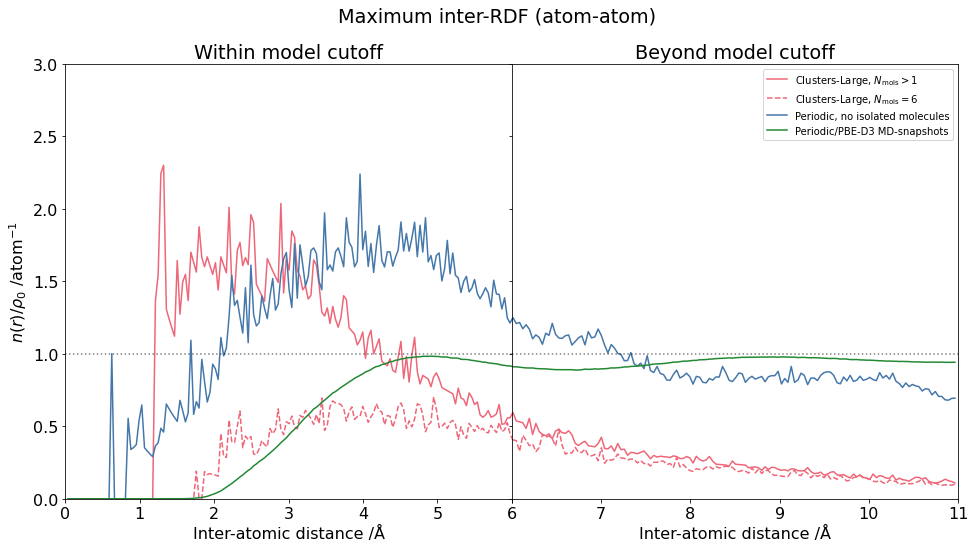

In [39]:

plt.rcParams.update({'font.size': fsize})

name_map = {
    'SD22N-1':'Clusters-Large, $N_\\text{mols}=1$',
    'SD22N-6':'Clusters-Large, $N_\\text{mols}=6$',
    'SD22NQQ-6':'Clusters-Small, $N_\\text{mols}=6$',
    'SD22N':'Clusters-Large, $N_\\text{mols}>1$',
    'SD22NQ':'Clusters-Medium',
    'SD22NQQ':'Clusters-Small',
    'Test-6':'Test, , $N_\\text{mols}=6$',
    'Test-11':'Test, , $N_\\text{mols}=11$',
    'IBM23-vscan':'Periodic, volume scans',
    'IBM23':'Periodic, no isolated molecules',
    'IBM23-MD':'Periodic, MD-snapshots',
    'Periodic-MD':'MD average from periodic models',
    'Cluster-MD':'MD average from cluster models',
    'MD':'MD reference', # Six models, 100 snapshots each
    'MD-npbc':'MD reference (no pbc)', # Six models, 100 snapshots each
}


#fig = plt.figure(figsize=(10,10))
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8*2, 8*1), sharey=True)

#ax.set_title('Neighbours per atom within the\ncutoffs used during training')
fig.suptitle('Maximum inter-RDF (atom-atom)')
ax1.set_title('Within model cutoff')
ax1.set_xlabel('Inter-atomic distance /Å')
ax1.set_ylabel('$n(r)/\\rho_0$ /atom$^{-1}$')
ax1.set_ylim([None,3])
ax1.set_xlim([None,6])
for name, data in coordination_histograms.items():
    print(name)
    n, r = data
    if 'SD22N' in name:
        if '6' in name:
            ax1.plot(r,n, '--', color=cset.red, label=name_map[name])
        else:
            ax1.plot(r,n, color=cset.red, label=name_map[name])
    elif 'IBM23' in name:
            ax1.plot(r,n, color=cset.blue, label=name_map[name])
ax1.plot(r_ref_inter,g_ref_inter, color=cset.green, label='Periodic/PBE-D3 MD-snapshots')
ax1.axhline(y=1.0, linestyle=':', color=cset.black, alpha=0.5)
#ax1.legend(loc='upper left', fontsize=fsize-6)


ax2.set_title('Beyond model cutoff')
ax2.set_xlabel('Inter-atomic distance /Å')
#ax2.set_ylabel('$n(r)/\\rho_0$ /atom$^{-1}$')
ax2.set_ylim([None,3])
ax2.set_xlim([6,rmax])
for name, data in coordination_histograms.items():
    print(name)
    n, r = data
    if 'SD22N' in name:
        if '6' in name:
            ax2.plot(r,n, '--', color=cset.red, label=name_map[name])
        else:
            ax2.plot(r,n, color=cset.red, label=name_map[name])
    elif 'IBM23' in name:
            ax2.plot(r,n, color=cset.blue, label=name_map[name])
ax2.plot(r_ref_inter,g_ref_inter, color=cset.green, label='Periodic/PBE-D3 MD-snapshots')
ax2.axhline(y=1.0, linestyle=':', color=cset.black, alpha=0.5)
ax2.legend(loc='upper right', fontsize=fsize-6)

ax2.set_xticklabels([None]+list(range(7,12)))
plt.subplots_adjust(wspace=0, hspace=0)

#plt.tight_layout()


In [40]:
def pathological_pairs(atoms, threshold, mic=False, offset=0):
    threshold = 1.0
    indices = []
    for i, a in enumerate(atoms):
        mID = a.arrays['molID']
        SI_mask = self_interaction_mask(mID)
        il = np.tril_indices(len(a), k=1)
        distances = a.get_all_distances(mic=mic)*SI_mask
        distances[il] = 0
        ids = np.where((distances>0) & (distances<threshold))
        if len(ids[0]) > 0:
            indices.append(i)
            if 'Samp' in a.info:
                print(f'Structure {i+1+offset} ({a.info["Samp"]}):')
            elif 'config_type' in a.info:
                print(f'Structure {i+1+offset} ({a.info["config_type"]}):')
            else:
                print(f'Structure {i+1+offset}:')
            for j,k in zip(*ids):
                d = distances[j,k]
                pair = a[[j,k]]
                id1, id2 = pair.arrays['molID']
                print(f'  Atom index {j} ({pair.symbols[0]}, molecule {id1}) and {k}  ({pair.symbols[1]}, molecule {id2}), distance={d:.3f}')
            print()
    return indices

In [484]:
threshold = 1.0
print('IBM pairs:') # offset by 3 indices compared to the xyz-file!
IBM_pairs = pathological_pairs(IBM23_dict['IBM23'], threshold=threshold, mic=True, offset=3)

IBM pairs:
Structure 783 (VolumeScans):
  Atom index 58 (H, molecule 3) and 103  (H, molecule 6), distance=0.908
  Atom index 73 (H, molecule 4) and 132  (H, molecule 8), distance=0.993

Structure 788 (VolumeScans):
  Atom index 81 (H, molecule 6) and 123  (H, molecule 9), distance=0.966

Structure 797 (VolumeScans):
  Atom index 38 (H, molecule 3) and 115  (O, molecule 11), distance=0.864
  Atom index 96 (H, molecule 9) and 118  (H, molecule 11), distance=0.629

Structure 798 (VolumeScans):
  Atom index 96 (H, molecule 9) and 118  (H, molecule 11), distance=0.843

Structure 809 (VolumeScans):
  Atom index 44 (O, molecule 4) and 57  (H, molecule 5), distance=0.968

Structure 845 (VolumeScans):
  Atom index 51 (H, molecule 4) and 157  (H, molecule 11), distance=0.928
  Atom index 54 (H, molecule 4) and 113  (H, molecule 8), distance=0.964



SD22N
SD22N-6
IBM23
SD22N
SD22N-6
IBM23


/tmp/ipykernel_297349/1131041282.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([None]+list(range(7,12)))


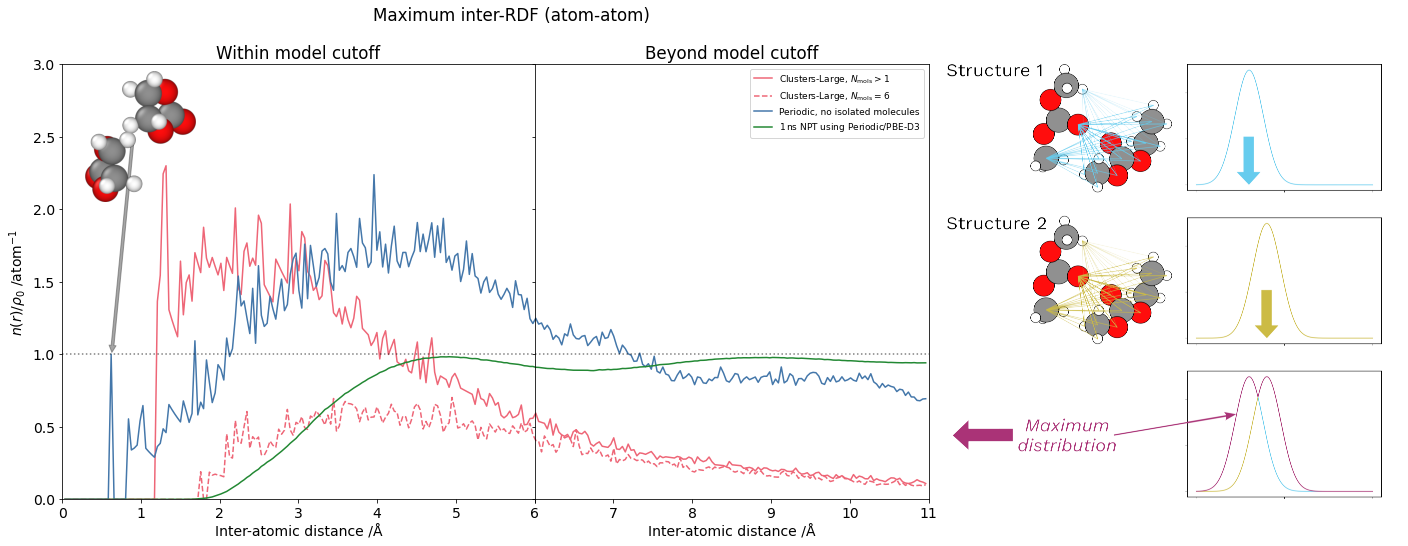

In [67]:
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams.update({'font.size': fsize-2})
name_map = {
    'SD22N-6':'Clusters-Large, $N_\\text{mols}=6$',
    'SD22N':'Clusters-Large, $N_\\text{mols}>1$',
    'IBM23':'Periodic, no isolated molecules',
}

ax1_img = mpimg.imread('../publication/tmp_plots/IBM23_pathological_vscan.png')
ax3_img = mpimg.imread('../publication/tmp_plots/rdf_schematic.png')

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(8*3, 8*1), sharey=True, gridspec_kw={'width_ratios': [1, 5/6, 1]})
fig.suptitle('Maximum inter-RDF (atom-atom)', x=0.385)

ax1.set_title('Within model cutoff')
ax1.set_xlabel('Inter-atomic distance /Å')
ax1.set_ylabel('$n(r)/\\rho_0$ /atom$^{-1}$')
ax1.set_ylim([None,3])
ax1.set_xlim([None,6])
for name, data in coordination_histograms.items():
    print(name)
    n, r = data
    if 'SD22N' in name:
        if '6' in name:
            ax1.plot(r,n, '--', color=cset.red, label=name_map[name])
        else:
            ax1.plot(r,n, color=cset.red, label=name_map[name])
    elif 'IBM23' in name:
            ax1.plot(r,n, color=cset.blue, label=name_map[name])
ax1.plot(r_ref_inter,g_ref_inter, color=cset.green, label='Periodic/PBE-D3 MD-snapshots')
ax1.axhline(y=1.0, linestyle=':', color=cset.black, alpha=0.5)

inset_ax1 = inset_axes(ax1, width="30%", height="30%", loc='upper left')
inset_ax1.imshow(ax1_img, zorder=-1)
inset_ax1.axis('off')
ax1.annotate("", xytext=(0.9, 2.5), xy=(0.63, 1.0),arrowprops=dict(arrowstyle="simple", color='#4c4c4c', alpha=0.5))


ax2.set_title('Beyond model cutoff')
ax2.set_xlabel('Inter-atomic distance /Å')
ax2.set_ylim([None,3])
ax2.set_xlim([6,rmax])
for name, data in coordination_histograms.items():
    print(name)
    n, r = data
    if 'SD22N' in name:
        if '6' in name:
            ax2.plot(r,n, '--', color=cset.red, label=name_map[name])
        else:
            ax2.plot(r,n, color=cset.red, label=name_map[name])
    elif 'IBM23' in name:
            ax2.plot(r,n, color=cset.blue, label=name_map[name])
ax2.plot(r_ref_inter,g_ref_inter, color=cset.green, label='1$\\,$ns NPT using Periodic/PBE-D3')
ax2.axhline(y=1.0, linestyle=':', color=cset.black, alpha=0.5)
ax2.legend(loc='upper right', fontsize=fsize-7)
ax2.set_xticklabels([None]+list(range(7,12)))

ax3.axis('off')
inset_ax3 = inset_axes(ax3, width="100%", height="100%", loc='center')
inset_ax3.imshow(ax3_img)
inset_ax3.axis('off')

plt.subplots_adjust(wspace=0, hspace=0)

SD22N
SD22N-6
IBM23
[0, 2, 4, 6]


/tmp/ipykernel_297349/2875671857.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ticks)


SD22N
SD22N-6
IBM23


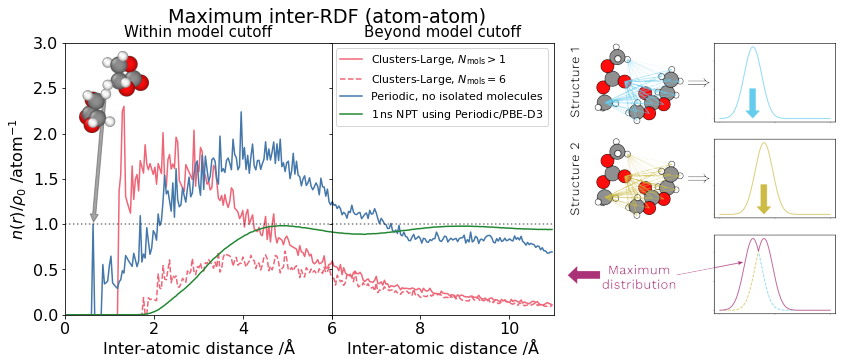

In [112]:
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

scale = 2
fsize = 8*scale
plt.rcParams.update({'font.size': fsize})

name_map = {
    'SD22N-6':'Clusters-Large, $N_\\text{mols}=6$',
    'SD22N':'Clusters-Large, $N_\\text{mols}>1$',
    'IBM23':'Periodic, no isolated molecules',
}

ax1_img = mpimg.imread('../publication/tmp_plots/IBM23_pathological_vscan.png')
ax3_img = mpimg.imread('../publication/tmp_plots/rdf_schematic.png')

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(7*scale, 2.5*scale), sharey=True, gridspec_kw={'width_ratios': [1, 5/6, 1.1]})
fig.suptitle('Maximum inter-RDF (atom-atom)', x=0.385)

ax1.set_title('Within model cutoff', fontsize=fsize-1)
ax1.set_xlabel('Inter-atomic distance /Å')
ax1.set_ylabel('$n(r)/\\rho_0$ /atom$^{-1}$')
ax1.set_ylim([None,3])
ax1.set_xlim([None,6])
for name, data in coordination_histograms.items():
    print(name)
    n, r = data
    if 'SD22N' in name:
        if '6' in name:
            ax1.plot(r,n, '--', color=cset.red, label=name_map[name])
        else:
            ax1.plot(r,n, color=cset.red, label=name_map[name])
    elif 'IBM23' in name:
            ax1.plot(r,n, color=cset.blue, label=name_map[name])
ax1.plot(r_ref_inter,g_ref_inter, color=cset.green, label='Periodic/PBE-D3 MD-snapshots')
ax1.axhline(y=1.0, linestyle=':', color=cset.black, alpha=0.5)
ticks = list(np.arange(0,7,2))
print(ticks)
ticks[-1] = None
ax1.set_xticklabels(ticks)


inset_ax1 = inset_axes(ax1, width="30%", height="30%", loc='upper left')
inset_ax1.imshow(ax1_img, zorder=-1)
inset_ax1.axis('off')
ax1.annotate("", xytext=(0.9, 2.5), xy=(0.63, 1.0),arrowprops=dict(arrowstyle="simple", color='#4c4c4c', alpha=0.5))


ax2.set_title('Beyond model cutoff', fontsize=fsize-1)
ax2.set_xlabel('Inter-atomic distance /Å')
ax2.set_ylim([None,3])
ax2.set_xlim([6,rmax])
for name, data in coordination_histograms.items():
    print(name)
    n, r = data
    if 'SD22N' in name:
        if '6' in name:
            ax2.plot(r,n, '--', color=cset.red, label=name_map[name])
        else:
            ax2.plot(r,n, color=cset.red, label=name_map[name])
    elif 'IBM23' in name:
            ax2.plot(r,n, color=cset.blue, label=name_map[name])
ax2.plot(r_ref_inter,g_ref_inter, color=cset.green, label='1$\\,$ns NPT using Periodic/PBE-D3')
ax2.axhline(y=1.0, linestyle=':', color=cset.black, alpha=0.5)
ax2.legend(loc='upper right', fontsize=fsize-5)
#ax2.set_xticklabels([None]+list(range(7,r[-1])))

ax3.axis('off')
inset_ax3 = inset_axes(ax3, width="100%", height="100%", loc='center')
inset_ax3.imshow(ax3_img)
inset_ax3.axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig('../publication/plots/part2_pair-coordination.pdf', format='pdf', dpi=1200)

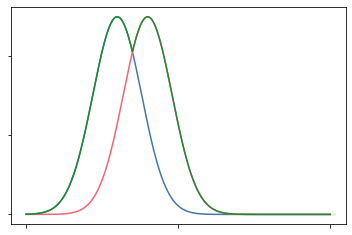

In [169]:
#test = [a for a in SD22N_dict['SD22N'] if a.info['Nmols'] == 2]
#test_rdf1, r = compute_rdf(test[:2], rmax=rmax, nbins=75, rho=rho_ref_inter, use_max=True, inter_only=True)
#test_rdf2, r = compute_rdf(test[2:4], rmax=rmax, nbins=75, rho=rho_ref_inter, use_max=True, inter_only=True)
x = np.linspace(0,10, 1000)
def gauss(x,m,s):
    return (2*np.pi*s**2)**-0.5*np.exp(-(x-m)**2/(2*s**2))


fig, ax = plt.subplots()
y1 = gauss(x,3,0.8)
y2 = gauss(x,4,0.8)
ax.plot(x, y1)
ax.plot(x, y2)
ax.plot(x, np.maximum(y1,y2))
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.savefig('../publication/playground/rdf.svg')